Dataset link= https://www.kaggle.com/datasets/camnugent/sandp500

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Load Dataset

In [2]:
df=pd.read_csv('/content/all_stocks_5yr.csv')

Exploring Dataset


In [3]:
df.shape# Check rows and columns



(619040, 7)

In [4]:
df.info() # Data types and null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


In [5]:
df.head() # Preview first 5 rows

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [6]:
df["date"]= pd.to_datetime(df["date"])# fixing date columns dtype.


In [7]:
df.isnull().sum()# cheaking null value

,0
date,0
open,11
high,8
low,8
close,0
volume,0
Name,0


In [8]:
df.dropna(inplace=True)#drop null values

In [9]:
df.duplicated().sum()# cheaking duplicated

np.int64(0)

 3. FEATURE ENGINEERING

In [10]:
df.sort_values(['Name', 'date']) # Sort by stock name and dat

,date,open,high,low,close,volume,Name
71611,2013-02-08,45.07,45.35,45.00,45.08,1824755,A
71612,2013-02-11,45.17,45.18,44.45,44.60,2915405,A
71613,2013-02-12,44.81,44.95,44.50,44.62,2373731,A
71614,2013-02-13,44.81,45.24,44.68,44.75,2052338,A
71615,2013-02-14,44.72,44.78,44.36,44.58,3826245,A
...,...,...,...,...,...,...,...
619035,2018-02-01,76.84,78.27,76.69,77.82,2982259,ZTS
619036,2018-02-02,77.53,78.12,76.73,76.78,2595187,ZTS
619037,2018-02-05,76.64,76.92,73.18,73.83,2962031,ZTS
619038,2018-02-06,72.74,74.56,72.13,73.27,4924323,ZTS


In [11]:
df['daily_return'] = df.groupby('Name')['close'].pct_change() # % change day over day
df['daily_return']

,daily_return
0,NaN
1,-0.019661
2,-0.013140
3,0.027330
4,-0.045703
...,...
619035,0.014206
619036,-0.013364
619037,-0.038421
619038,-0.007585


In [12]:
df['roll_7'] = df.groupby('Name')['close'].transform(lambda x: x.rolling(7).mean())
df['roll_7']

,roll_7
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
619035,78.535714
619036,78.314286
619037,77.540000
619038,76.565714


In [13]:
df['roll_30'] = df.groupby('Name')['close'].transform(lambda x: x.rolling(30).mean())
df['roll_30']

,roll_30
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
619035,75.069333
619036,75.202000
619037,75.239333
619038,75.272333


DESCRIPTIVE STATISTICS

In [14]:
df['daily_return'].describe() # Mean, std, min, max, quartiles


,daily_return
count,618524.000000
mean,0.000541
std,0.016060
min,-0.626183
25%,-0.006793
50%,0.000635
75%,0.008105
max,1.009513


In [15]:
print("Skewness:", df['daily_return'].skew()) # Is distribution symmetric?


Skewness: 0.19695152752076722


In [16]:
print("Kurtosis:", df['daily_return'].kurt()) # How heavy are the tails?

Kurtosis: 63.3086787408468


NFERENTIAL STATISTICS

In [17]:
clean_returns = df['daily_return'].dropna()
t_stat, p_value = stats.ttest_1samp(clean_returns, 0)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
# If p_value < 0.05, the mean daily return is significantly different from zero

T-statistic: 26.5019, P-value: 0.0000


 VISUALIZATIONS

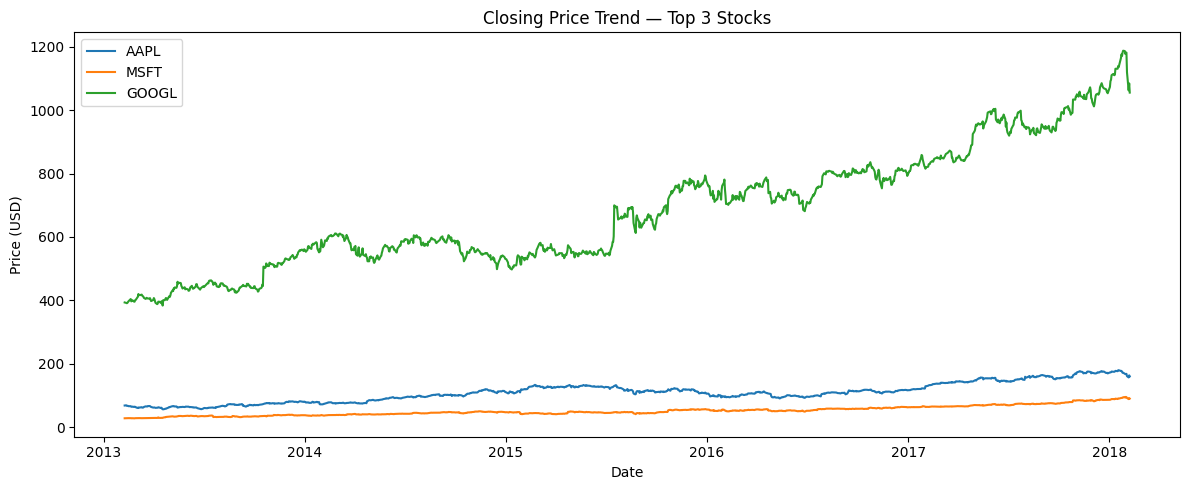

In [18]:

# Ensure date format is correct
df['date'] = pd.to_datetime(df['date'])

# Filter only required stocks once (more efficient)
top_stocks = ['AAPL', 'MSFT', 'GOOGL']
filtered_df = df[df['Name'].isin(top_stocks)]

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

for stock in top_stocks:
    subset = filtered_df[filtered_df['Name'] == stock].sort_values('date')
    ax.plot(subset['date'], subset['close'], label=stock)

# Labels and styling
ax.set_title("Closing Price Trend — Top 3 Stocks")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()

plt.tight_layout()
plt.savefig("price_trend.png", dpi=150)
plt.show()

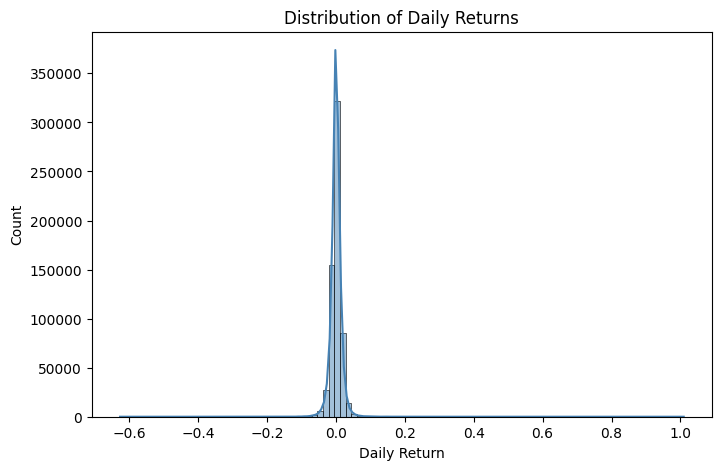

In [19]:
# 6b. Distribution of daily returns
plt.figure(figsize=(8, 5))
sns.histplot(clean_returns, bins=100, kde=True, color='steelblue')
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.savefig("return_distribution.png", dpi=150)
plt.show()

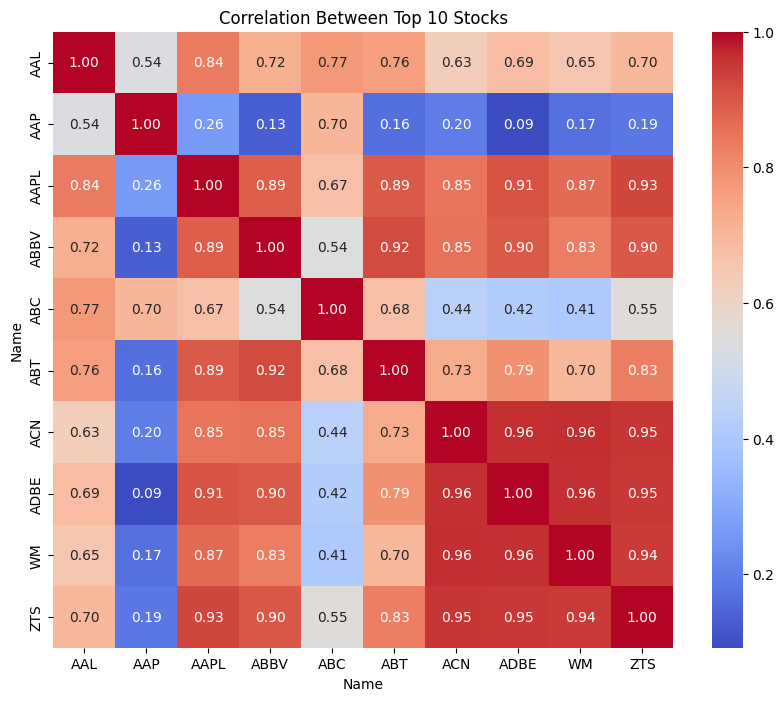

In [20]:
# 6c. Correlation heatmap of top 10 stocks by data volume
top10 = df['Name'].value_counts().head(10).index
pivot = df[df['Name'].isin(top10)].pivot_table(index='date', columns='Name', values='close')
plt.figure(figsize=(10, 8))
sns.heatmap(pivot.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Between Top 10 Stocks")
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

**INSIGHTS**

1. AAPL, MSFT, and GOOGL show consistent upward price trends over time, indicating strong long-term growth.
2. The average daily return is slightly positive, suggesting that the market generally trends upward.
3. The distribution of daily returns is slightly right-skewed, meaning extreme positive returns occur more frequently than extreme negative returns.
4. High correlation exists between major stocks, especially within the same sector, indicating similar movement patterns.
5. Volatility spikes are observed during major global events, showing that the market is sensitive to external factors.

**INTERPRETATION**

The stock market demonstrates steady growth but is affected by external economic and global events.
Highly correlated stocks suggest that investing in similar sectors may not provide effective diversification.
Investors should analyze both return and risk (volatility) before making decisions.

**FINAL CONCLUSION**

Top-performing stocks such as AAPL and MSFT provide stable long-term returns.
However, market volatility indicates inherent risk.
A diversified portfolio across different sectors is recommended to balance risk and return.

In [21]:
df.to_csv("Stock_cleaned_data.csv", index=False)